In [4]:
pip install numpy matplotlib torch scikit-learn emcee scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import emcee # Für Bayes-Inferenz
import scipy.optimize as op

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running on device: {device}")

np.random.seed(42)
torch.manual_seed(42)

Running on device: cpu


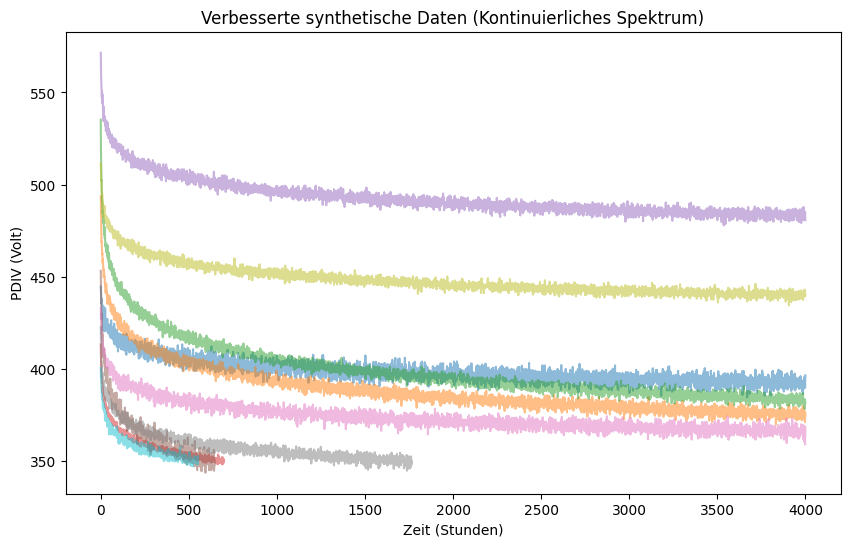

In [ ]:
def generate_synthetic_motor_data(n_samples=1000): # Erhöht auf 1000 Samples
    all_curves = []
    all_lifetimes = []
    
    # K liegt laut Tabelle zwischen ca. 400 und 600
    # n liegt zwischen ca. 0.018 und 0.047
    
    for _ in range(n_samples):
        # K und n aus einer Verteilung (Uniform)
        K_sim = np.random.uniform(400, 600)
        n_sim = np.random.uniform(0.015, 0.050)
        
        # Formel umgestellt: t = (PDIV / K) ^ (-1/n)
        limit_pdiv = 350.0
        life_sim = int((limit_pdiv / K_sim) ** (-1 / n_sim))
        
        # (Nicht zu kurz für das 200er Fenster, abeer nicht sher lang)
        if life_sim < 250: life_sim = 250
        if life_sim > 4000: life_sim = 4000
            
        # Zeitachse
        t = np.linspace(1, life_sim, life_sim)
        
        # Kurve berechnen
        pdiv_curve = inverse_power_model(t, K_sim, n_sim)
        
        # Rauschen hinzufügen
        noise_level = np.random.uniform(1.0, 3.0)
        noise = np.random.normal(0, noise_level, size=pdiv_curve.shape)
        pdiv_curve_noisy = pdiv_curve + noise
        
        all_curves.append(pdiv_curve_noisy)
        all_lifetimes.append(life_sim)
        
    return all_curves, np.array(all_lifetimes)

# daten generieren
raw_curves, raw_lifetimes = generate_synthetic_motor_data(n_samples=1000)


for i in range(10):
    plt.plot(raw_curves[i], alpha=0.5)
plt.xlabel("Zeit (Stunden)")
plt.ylabel("PDIV (Volt)")
plt.title("Verbesserte synthetische Daten (Kontinuierliches Spektrum)")
plt.show()

In [ ]:
# Parameter
INPUT_WINDOW = 150  #nur die ersten 150 Stunden

X_data = []
y_data = []
valid_full_curves = [] # hier die kompletten Kurven

# Slicing Loop
for i, curve in enumerate(raw_curves):
    # nur Motoren nutzen, die > INPUT_WINDOW haben
    if len(curve) > INPUT_WINDOW:
        # Input: Die ersten n Datenpunkte
        input_seq = curve[:INPUT_WINDOW]
        
        # Output: Die echte Lebensdauer
        target_life = raw_lifetimes[i]
        
        X_data.append(input_seq)
        y_data.append(target_life)
        valid_full_curves.append(curve) 

X_data = np.array(X_data)
y_data = np.array(y_data)

# Skalierung
scaler_X = MinMaxScaler()
X_data_flat = X_data.reshape(-1, 1) 
scaler_X.fit(X_data_flat)
X_scaled = scaler_X.transform(X_data_flat).reshape(X_data.shape)

# Reshape (Batch, Channels, Sequence_Length)
X_final = X_scaled.reshape(-1, 1, INPUT_WINDOW)
y_final = y_data.reshape(-1, 1).astype(np.float32)

# Train/Test Split
X_train, X_test, y_train, y_test, curves_train, curves_test = train_test_split(
    X_final, y_final, valid_full_curves, test_size=0.2, random_state=42
)

# Datase
class MotorDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(MotorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader = DataLoader(MotorDataset(X_test, y_test), batch_size=32, shuffle=False)

print(f"Trainingsdaten Shape: {X_train.shape}")
print(f"Testdaten Shape: {X_test.shape}")
print(f"Anzahl voller Kurven im Testset: {len(curves_test)}")

Trainingsdaten Shape: (800, 1, 150)
Testdaten Shape: (200, 1, 150)
Anzahl voller Kurven im Testset: 200


In [ ]:
#CNN Modell
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm1d(out_channels)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = self.relu(out)
        return out

class ResCNN(nn.Module):
    def __init__(self):
        super(ResCNN, self).__init__()
        # Input Channels: 1 (PDIV Kurve)
        self.conv1 = nn.Conv1d(1, 16, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm1d(16)
        self.relu = nn.ReLU(inplace=True)
        
        # Residual Blocks
        self.layer1 = self._make_layer(16, 16, 2, stride=1)
        self.layer2 = self._make_layer(16, 32, 2, stride=2)
        self.layer3 = self._make_layer(32, 64, 2, stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool1d(1)
        
        # Fully Connected Layer für Regression (Output: Lebensdauer)
        self.fc = nn.Linear(64, 1)

    def _make_layer(self, in_channels, out_channels, blocks, stride):
        layers = []
        layers.append(ResBlock(in_channels, out_channels, stride))
        for _ in range(1, blocks):
            layers.append(ResBlock(out_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# Modell 
model = ResCNN().to(device)
criterion = nn.MSELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

NameError: name 'nn' is not defined

Starte Training...
Epoch 10/100, Train Loss: 504588.0, Val Loss: 2241649.6
Epoch 20/100, Train Loss: 336103.2, Val Loss: 238261.5
Epoch 30/100, Train Loss: 277200.7, Val Loss: 849296.4
Epoch 40/100, Train Loss: 158437.0, Val Loss: 1414959.5
Epoch 50/100, Train Loss: 199345.2, Val Loss: 1921488.4
Epoch 60/100, Train Loss: 149879.4, Val Loss: 124723.9
Epoch 70/100, Train Loss: 105061.6, Val Loss: 168147.9
Epoch 80/100, Train Loss: 127207.9, Val Loss: 2132407.0
Epoch 90/100, Train Loss: 105785.6, Val Loss: 54471.9
Epoch 100/100, Train Loss: 114754.2, Val Loss: 164537.2


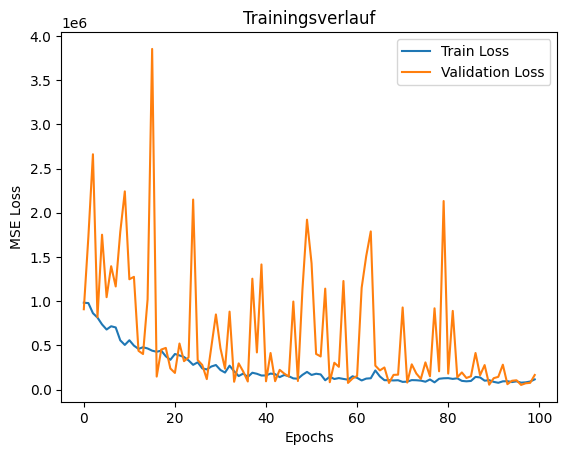

In [68]:
EPOCHS = 100
train_losses = []
test_losses = []

print("Starte Training...")

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
    
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    # Validierung
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * inputs.size(0)
            
    epoch_val_loss = val_loss / len(test_loader.dataset)
    test_losses.append(epoch_val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS}, Train Loss: {epoch_loss:.1f}, Val Loss: {epoch_val_loss:.1f}")

plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('Trainingsverlauf')
plt.legend()
plt.show()

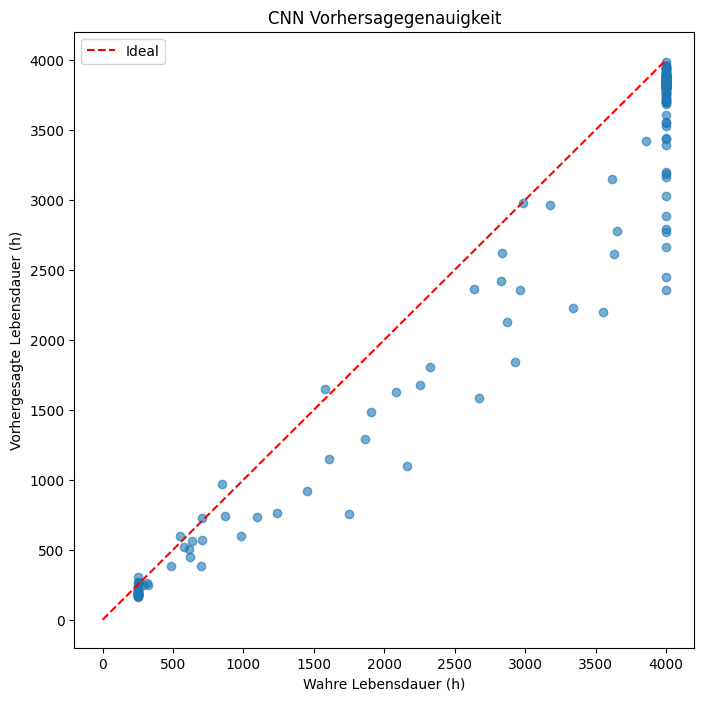

In [69]:
model.eval()
predictions = []
actuals = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        preds = model(inputs)
        predictions.extend(preds.cpu().numpy())
        actuals.extend(labels.numpy())

predictions = np.array(predictions).flatten()
actuals = np.array(actuals).flatten()

plt.figure(figsize=(8,8))
plt.scatter(actuals, predictions, alpha=0.6)
plt.plot([0, max(actuals)], [0, max(actuals)], 'r--', label='Ideal')
plt.xlabel('Wahre Lebensdauer (h)')
plt.ylabel('Vorhergesagte Lebensdauer (h)')
plt.title('CNN Vorhersagegenauigkeit')
plt.legend()
plt.show()

In [ ]:
r2 = r2_score(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"R² Score: {r2:.4f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} Stunden")



R² Score: 0.9246
MSE (Mean Squared Error): 164537.16
RMSE (Root Mean Squared Error): 405.63 Stunden


In [ ]:
# 
sample_idx = 3 # um andere motoren zu prüfen
input_seq_tensor = torch.tensor(X_test[sample_idx]).unsqueeze(0).float().to(device)
cnn_predicted_lifetime = model(input_seq_tensor).item()

# orginale Messdaten der ersten 200h (unskaliert)
input_seq_scaled = X_test[sample_idx].flatten()
input_seq_real = scaler_X.inverse_transform(input_seq_scaled.reshape(-1, 1)).flatten()
t_observed = np.arange(1, INPUT_WINDOW + 1) # Zeit 1 bis 200

print(f"CNN Vorhersage Lebensdauer: {cnn_predicted_lifetime:.1f} h")
print(f"Wahre Lebensdauer: {y_test[sample_idx].item():.1f} h")


# BAYES

# Log-Likelihood: Wie gut passt das Modell zu den beobachteten 200 Punkten?
def log_likelihood(theta, t, y_obs, y_err):
    K, n = theta
    model_vals = inverse_power_model(t, K, n)
    sigma2 = y_err**2
    return -0.5 * np.sum((y_obs - model_vals)**2 / sigma2 + np.log(sigma2))

# CNN-Ergebnis als log-prior

def log_prior(theta, predicted_life):
    K, n = theta
    
    # Grenzen (Physikalisch Plausibil=
    if not (200 < K < 800 and 0.001 < n < 0.2):
        return -np.inf
    
    # Soft Constraint: Bei t = predicted_life sollte PDIV ca. 350 sein
    # Wir bestrafen Abweichungen davon
    expected_end_pdiv = 350.0 
    model_end_pdiv = inverse_power_model(predicted_life, K, n)
    
    # Gaussian Prior um den Endpunkt
    return -0.5 * ((model_end_pdiv - expected_end_pdiv) / 50.0)**2

# Log-Probability (Posterior)
def log_probability(theta, t, y_obs, y_err, predicted_life):
    lp = log_prior(theta, predicted_life)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, t, y_obs, y_err)

# MCMC
# Startwerte (K, n)
initial_guess = [500, 0.03] 
n_walkers = 32
ndim = 2
# Initialisierung der Walker um den Startwert herum
pos = initial_guess + 1e-4 * np.random.randn(n_walkers, ndim)

sampler = emcee.EnsembleSampler(n_walkers, ndim, log_probability, args=(t_observed, input_seq_real, 2.0, cnn_predicted_lifetime))

print("Starte MCMC Sampling:")
sampler.run_mcmc(pos, 2000, progress=True)

# Ergebnisse extrahieren ( die ersten 500 Schritte als "Burn-in" verwerfen)
flat_samples = sampler.get_chain(discard=500, thin=15, flat=True)
K_median, n_median = np.median(flat_samples, axis=0)

print(f"Gefundene Parameter: K={K_median:.2f}, n={n_median:.4f}")

You must install the tqdm library to use progress indicators with emcee


CNN Vorhersage Lebensdauer: 3813.5 h
Wahre Lebensdauer: 4000.0 h
Starte MCMC Sampling...
Gefundene Parameter: K=580.73, n=0.0339


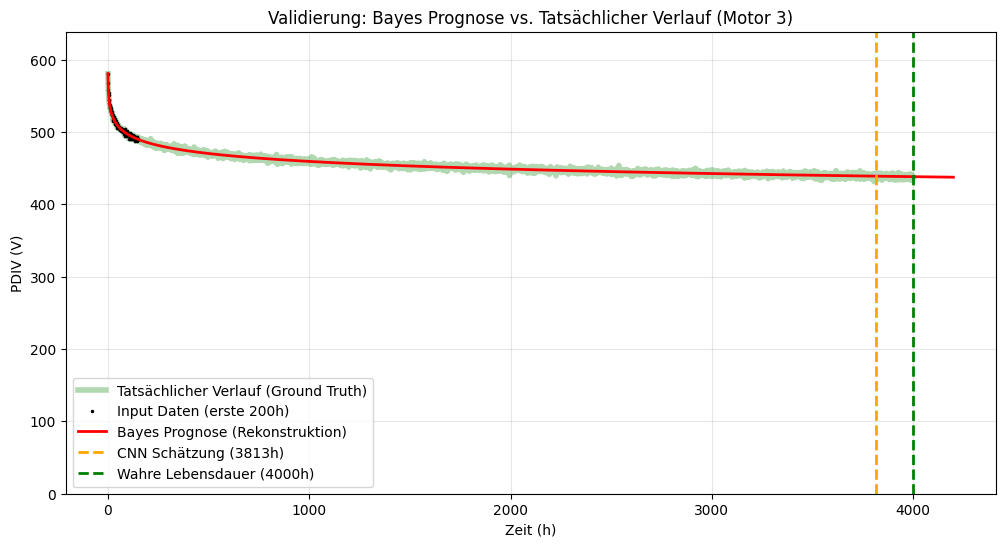

In [ ]:
# Zeitachse
max_time_horizon = int(max(cnn_predicted_lifetime, y_test[sample_idx].item())) + 200
t_future = np.arange(1, max_time_horizon)

# Bayes Prognose-Kurve
predicted_curve = inverse_power_model(t_future, K_median, n_median)

# ECHTE Kurve aus den Testdaten (die restlichen 80%)
true_full_curve = curves_test[sample_idx]
t_true = np.arange(1, len(true_full_curve) + 1)

plt.figure(figsize=(12, 6))

# Wahre gesamte Daten plotten
plt.plot(t_true, true_full_curve, color='green', alpha=0.3, linewidth=4, label='Tatsächlicher Verlauf (Ground Truth)')

# Plot (Input die ersten 200h)
plt.plot(t_observed, input_seq_real, 'k.', markersize=3, label='Input Daten (erste 200h)')

# Plot Bayes Vorherdage
plt.plot(t_future, predicted_curve, 'r-', linewidth=2, label='Bayes Prognose (Rekonstruktion)')

# Vertikale Linien für Lebensdauer
plt.axvline(x=cnn_predicted_lifetime, color='orange', linestyle='--', linewidth=2, label=f'CNN Schätzung ({int(cnn_predicted_lifetime)}h)')
plt.axvline(x=y_test[sample_idx].item(), color='green', linestyle='--', linewidth=2, label=f'Wahre Lebensdauer ({int(y_test[sample_idx].item())}h)')

plt.xlabel('Zeit (h)')
plt.ylabel('PDIV (V)')
plt.title(f'Validierung: Bayes Prognose vs. Tatsächlicher Verlauf (Motor {sample_idx})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(0, max(input_seq_real)*1.1) # Y-Achse anpassen
plt.show()

In [1]:
predicted_curve

NameError: name 'predicted_curve' is not defined